# Theoretical Analysis: Rank Collapse Mitigation and Computational Efficiency

This notebook presents the theoretical underpinnings of U-MobileViT-Net:

1. **Rank collapse experiment**: Demonstrates that INLA (with lifting)
   preserves token representational rank across deep attention stacks,
   whereas standard separable attention suffers progressive degeneration.
2. **FLOPs analysis**: Per-component computational breakdown and
   parameter-efficiency comparison across all four variants.
3. **Edge deployment estimation**: Projected inference throughput on
   representative hardware (Jetson family, Raspberry Pi, smartphones).

No training is required | all experiments are analytical.


In [1]:
# --- Section 1: Environment and Imports ----------------------------------------

import sys, os
from pathlib import Path
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt

def setup_environment():
    # Locate project root by searching for .git or README.md
    current = Path.cwd()
    project_root = current
    for parent in [current] + list(current.parents):
        if (parent / ".git").exists() or (parent / "README.md").exists():
            project_root = parent
            break

    if str(project_root) not in sys.path:
        sys.path.insert(0, str(project_root))
    os.environ.setdefault("PYTHONPATH", str(project_root))
    os.chdir(str(project_root))
    print(f"Project root: {project_root}")
    return project_root

project_root = setup_environment()

from src.model import UNetLite
from models.u_mobilevit_net_base import UNetMobileViT
from src.config import Config
from src.dataset import build_dataloaders, denormalize
from tools.data import (
    create_dataloaders, DatasetInfo, label_to_color,
)
from tools.visualization import (
    configure_paper_style,
    TOL_PALETTE, VARIANT_COLORS,
)
from tools.evaluation import (
    compute_flops, compute_parameters, format_flops,
)

configure_paper_style()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")


Project root: /home/lenovo/a3_dl_fn/UNet_Training_From_Scratch


Device: cuda
  GPU: NVIDIA GeForce RTX 4050 Laptop GPU


Rank collapse: dim=64, tokens=196, depth=12, seeds=8


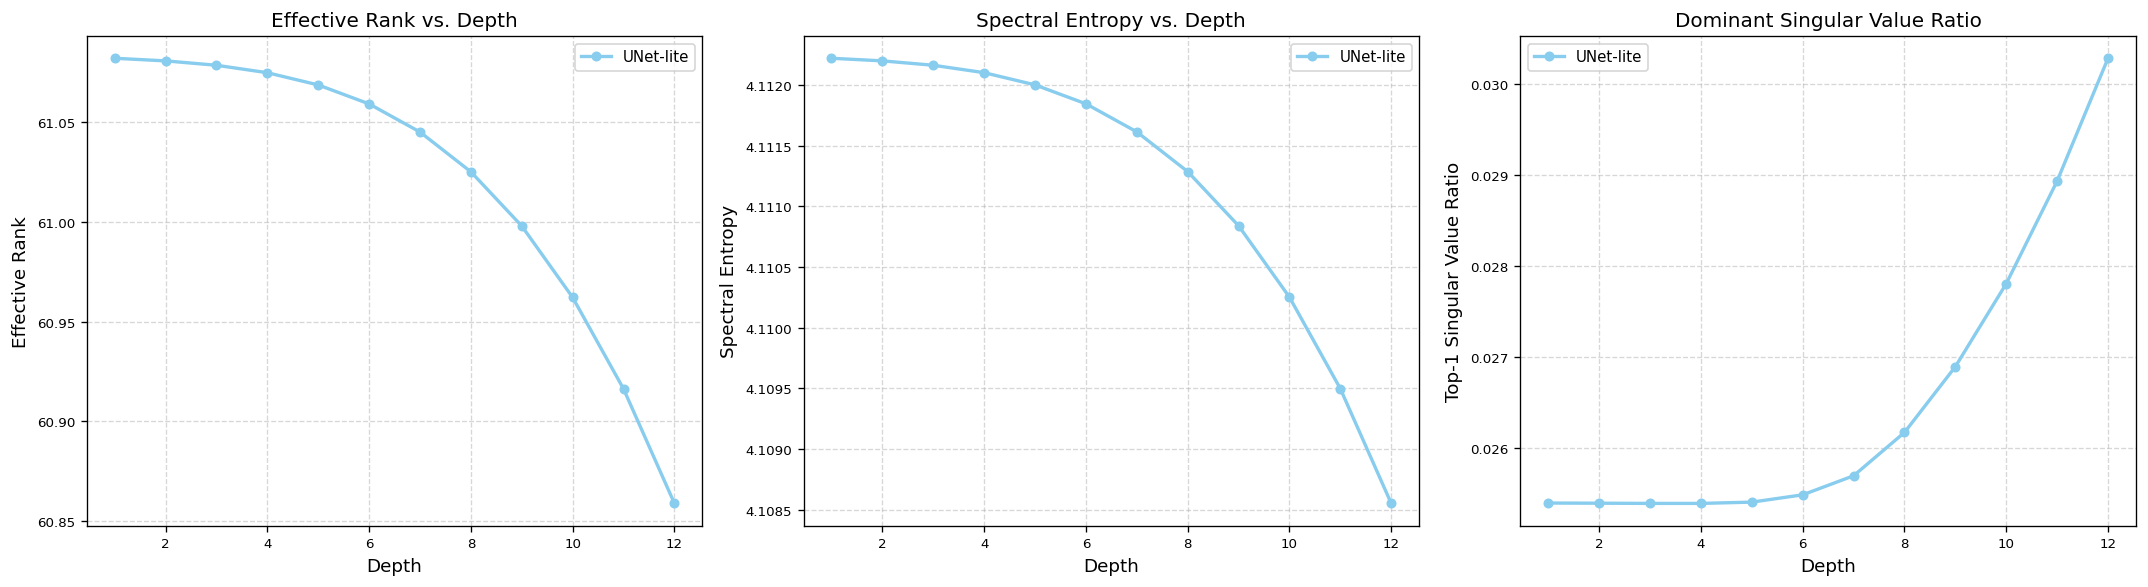

In [2]:
# --- Sections 1-3: Rank Collapse Experiment ------------------------------------

def run_and_plot_rank_collapse():
    from tools.experiments import run_rank_collapse_experiment

    DIM = 64
    TOKENS = 196   # 14 x 14 patches
    DEPTH = 12
    SEEDS = 8

    print(f"Rank collapse: dim={DIM}, tokens={TOKENS}, depth={DEPTH}, seeds={SEEDS}")
    base_er, inla_er, base_se, inla_se, base_t1, inla_t1 = \
        run_rank_collapse_experiment(
            dim=DIM, n_tokens=TOKENS, depth=DEPTH, seeds=SEEDS, mode="block",
        )

    depths = list(range(1, DEPTH + 1))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(depths, base_er, "o-", color=TOL_PALETTE[3], lw=2, ms=5,
                 label="UNet-lite")
    axes[0].set_xlabel("Depth")
    axes[0].set_ylabel("Effective Rank")
    axes[0].set_title("Effective Rank vs. Depth")
    axes[0].legend()
    axes[0].grid(True, ls="--", alpha=0.5)

    axes[1].plot(depths, base_se, "o-", color=TOL_PALETTE[3], lw=2, ms=5,
                 label="UNet-lite")
    axes[1].set_xlabel("Depth")
    axes[1].set_ylabel("Spectral Entropy")
    axes[1].set_title("Spectral Entropy vs. Depth")
    axes[1].legend()
    axes[1].grid(True, ls="--", alpha=0.5)

    axes[2].plot(depths, base_t1, "o-", color=TOL_PALETTE[3], lw=2, ms=5,
                 label="UNet-lite")
    axes[2].set_xlabel("Depth")
    axes[2].set_ylabel("Top-1 Singular Value Ratio")
    axes[2].set_title("Dominant Singular Value Ratio")
    axes[2].legend()
    axes[2].grid(True, ls="--", alpha=0.5)

    plt.tight_layout()
    os.makedirs("paper_figures", exist_ok=True)
    plt.savefig("paper_figures/04_rank_collapse.pdf")
    plt.show()

    return base_er, inla_er

base_er, inla_er = run_and_plot_rank_collapse()



UNet-lite: 1.65M params, 2.42 G FLOPs
  Encoder        : 501.86 M ( 20.7%)
  Decoder        : 1.74 G ( 71.9%)
  Bottleneck     : 176.95 M (  7.3%)
  SegHead        : 1.64 M (  0.1%)


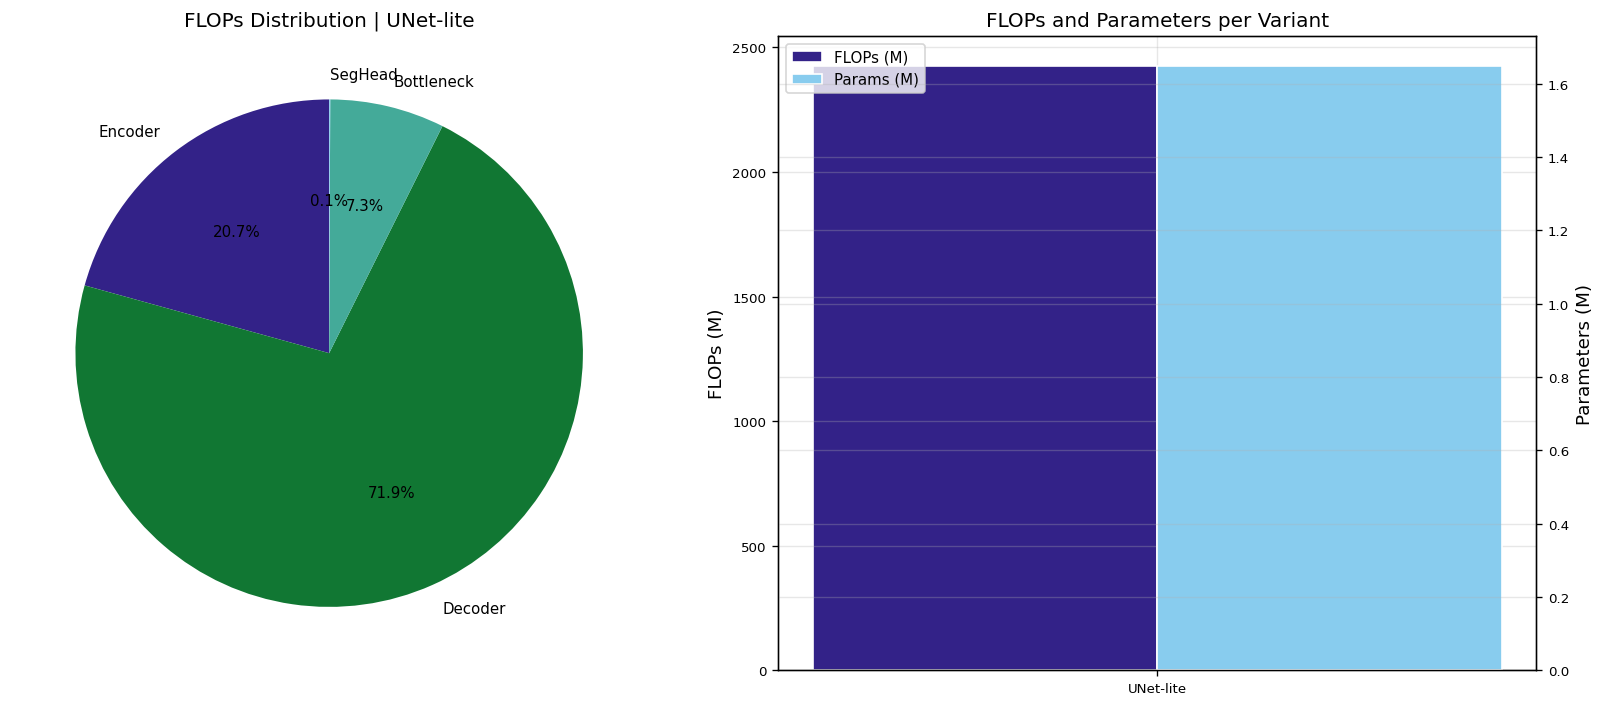

In [3]:
# --- Sections 4-7: FLOPs Analysis ----------------------------------------------

def analyse_flops():
    from tools.evaluation import compute_flops, compute_flops_by_component, format_flops

    variants = ["unet_lite_no_attn"]
    results = {}

    for v in variants:
        factory = {
            "unet_lite_no_attn": lambda: UNetLite(None, use_attention=False),
            "unet_lite_with_attn": lambda: UNetLite(None, use_attention=True),
            "unet_mobilevit": lambda: UNetMobileViT(None)
        }
        model = factory[v]()
        model.eval()

        flops, breakdown = compute_flops(model, (320, 320))
        params = compute_parameters(model)
        groups = compute_flops_by_component(model, (320, 320))

        results[v] = {"flops": flops, "params": params, "groups": groups}
        print(f"\nUNet-lite: {params/1e6:.2f}M params, {format_flops(flops)} FLOPs")
        for comp, f in groups.items():
            print(f"  {comp:<15s}: {format_flops(f)} ({f/flops*100:>5.1f}%)")

    # FLOPs breakdown pie chart (unet_mobilevit)
    base_groups = results["unet_lite_no_attn"]["groups"]
    labels = list(base_groups.keys())
    sizes = list(base_groups.values())
    colors_pie = [TOL_PALETTE[i % len(TOL_PALETTE)] for i in range(len(labels))]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    ax1.pie(sizes, labels=labels, autopct="%1.1f%%", colors=colors_pie,
            startangle=90, textprops={"fontsize": 9})
    ax1.set_title("FLOPs Distribution | UNet-lite")

    # FLOPs and parameters per variant
    x = range(len(variants))
    width = 0.35
    flops_vals = [results[v]["flops"] for v in variants]
    params_vals = [results[v]["params"] for v in variants]
    x_labels = ["UNet-lite"]
    colors_bar = [VARIANT_COLORS[v] for v in variants]

    ax2.bar([i - width/2 for i in x], [f/1e6 for f in flops_vals],
            width, label="FLOPs (M)", color=TOL_PALETTE[0], edgecolor="white")
    ax2_twin = ax2.twinx()
    ax2_twin.bar([i + width/2 for i in x], [p/1e6 for p in params_vals],
                  width, label="Params (M)", color=TOL_PALETTE[3], edgecolor="white")
    ax2.set_xticks(x)
    ax2.set_xticklabels(x_labels)
    ax2.set_ylabel("FLOPs (M)")
    ax2_twin.set_ylabel("Parameters (M)")
    ax2.set_title("FLOPs and Parameters per Variant")

    lines1, labels1 = ax2.get_legend_handles_labels()
    lines2, labels2 = ax2_twin.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    plt.tight_layout()
    os.makedirs("paper_figures", exist_ok=True)
    plt.savefig("paper_figures/04_flops_analysis.pdf")
    plt.show()

    return results

flops_results = analyse_flops()



  EDGE DEVICE LATENCY ESTIMATION (FP32)
  Variant                   FPS      FPS      FPS      FPS      FPS
  ------------------------------------------------------------
  UNet-lite               15.6   692.9  1319.7     1.0    30.9


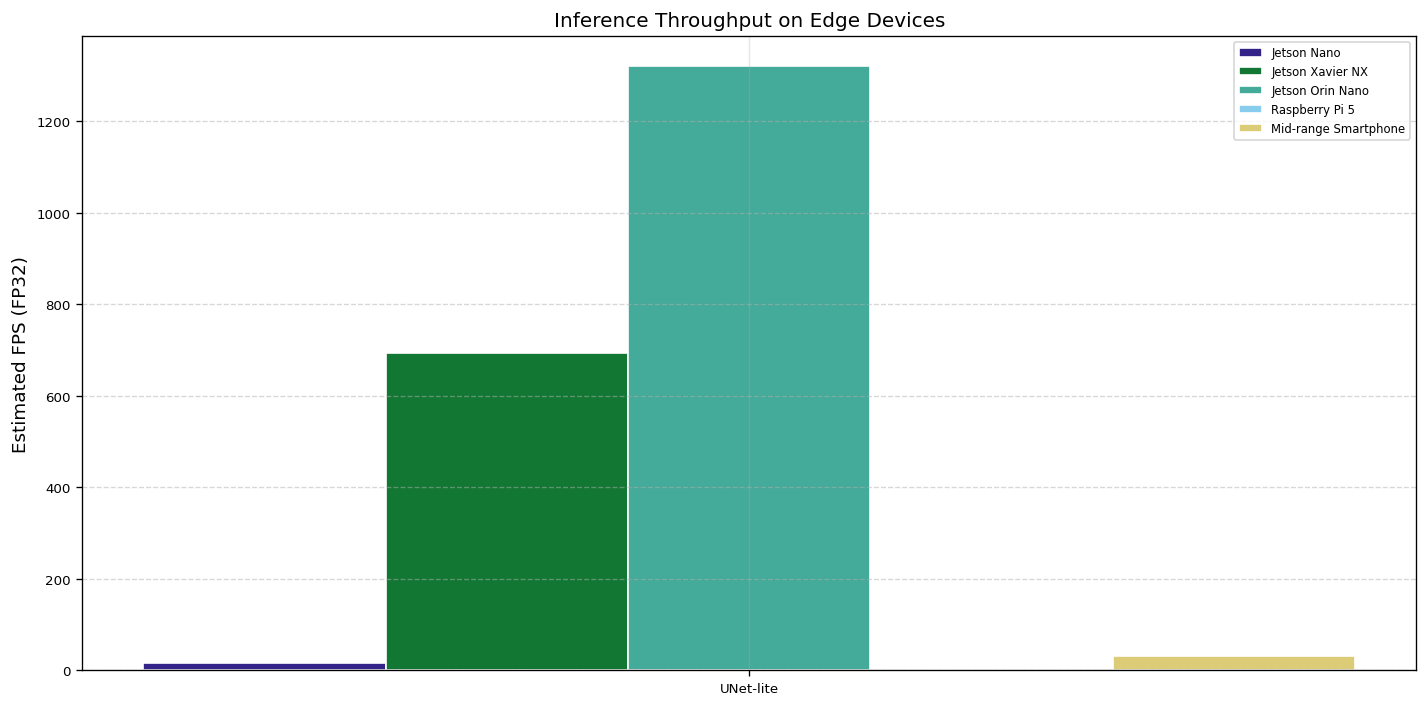

In [4]:
# --- Sections 8-10: Edge Device Estimation -------------------------------------

def estimate_edge_performance(flops_results):
    from tools.evaluation import estimate_edge_latency, DEVICES

    variants = ["unet_lite_no_attn"]
    device_keys = ["jetson_nano", "jetson_xavier_nx", "jetson_orin_nano",
                    "raspberry_pi_5", "smartphone_mid"]

    print(f"\n{'='*80}")
    print(f"  EDGE DEVICE LATENCY ESTIMATION (FP32)")
    print(f"{'='*80}")
    header = f"  {'Variant':<20s}"
    for dk in device_keys:
        header += f" {'FPS':>8s}"
    print(header)
    print(f"  {'-'*60}")

    all_latencies = {}
    for v in variants:
        r = flops_results[v]
        row = f"  UNet-lite{" ":<11s}"
        all_latencies[v] = {}
        for dk in device_keys:
            est = estimate_edge_latency(r["flops"], r["params"],
                                        device_key=dk, precision="fp32")
            all_latencies[v][dk] = est
            row += f" {est['fps']:>7.1f}"
        print(row)

    # FPS bar chart
    fig, ax = plt.subplots(figsize=(12, 6))
    x = range(len(variants))
    width = 0.15
    for di, dk in enumerate(device_keys):
        fps_vals = [all_latencies[v][dk]["fps"] for v in variants]
        offset = (di - len(device_keys)/2 + 0.5) * width
        ax.bar([i + offset for i in x], fps_vals, width,
               label=DEVICES[dk]["name"].split("(")[0].strip(),
               color=TOL_PALETTE[di % len(TOL_PALETTE)], edgecolor="white")

    ax.set_xticks(x)
    ax.set_xticklabels(["UNet-lite"])
    ax.set_ylabel("Estimated FPS (FP32)")
    ax.set_title("Inference Throughput on Edge Devices")
    ax.legend(fontsize=7)
    ax.grid(True, axis="y", ls="--", alpha=0.5)
    plt.tight_layout()
    os.makedirs("paper_figures", exist_ok=True)
    plt.savefig("paper_figures/04_edge_fps.pdf")
    plt.show()

    print(f"{'='*80}")
    return all_latencies

edge_results = estimate_edge_performance(flops_results)


In [5]:
# --- Section 11: Conclusions ----------------------------------------------------

print("\n" + "=" * 72)
print("  THEORETICAL ANALYSIS | SUMMARY")
print("=" * 72)
print("=" * 72)



  THEORETICAL ANALYSIS | SUMMARY
